# Import data

In [ ]:


import os
import time
import warnings

import numpy as np
import pandas as pd
import patsy
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
from scipy.special import expit
from statsmodels.stats.mediation import Mediation
from statsmodels.stats.outliers_influence import variance_inflation_factor
from tqdm import tqdm

warnings.filterwarnings("ignore", category=RuntimeWarning)

# Cleaned imports
import os
import sys
import warnings
from glob import glob

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xg
import numpy as np
import random
import numpy as np
import os
import torch

# add project src folders to PYTHONPATH for local imports
sys.path.extend([
    "/home/amrit/pipeline/src",
    "d:/pipeline/src",
    "/mnt/d/pipeline/src",
])
# runtime configuration
warnings.filterwarnings("ignore")
pd.set_option('display.max_rows', 50)
pd.set_option('display.max_columns', 1000)



def set_all_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    try:
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    except ImportError:
        pass
    try:
        import tensorflow as tf
        tf.random.set_seed(seed)
    except ImportError:
        pass


def fix_all_random_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        
randomSeed = 42

# Set the seed for reproducibility
fix_all_random_seeds(randomSeed)

# Colors 

In [ ]:

color_dict = {
    "dark_red1" : "#c23537",
    "dark_red2" : "#d95d5b",
    "light_red1" : "#ea999c",
    "light_red2" : "#f8c9c7",

    "light_blue1" : "#c1e3fa",
    "light_blue2" : "#91c3e8",
    "dark_blue1" : "#0067a8",
    "dark_blue2" : "#4c8fca",
    
    'light_green1' : "#56aa3e",
    'light_green2' : "#95c36e",
    'dark_green1' : "#1e662a",
    'dark_green2' : "#3c892d",
    

}

# Proteomics

In [ ]:


SCRIPT_DIR = "./data/"
SOURCE_FILE = os.path.join(SCRIPT_DIR, "source_population_with_retinal_scores.csv")
CLINICAL_FILE = os.path.join(SCRIPT_DIR, "final_df_HTN_DB_Status.csv")
OUTPUT_DIR = os.path.join(SCRIPT_DIR, "outputs")

COVARIATE_FORMULA = "age + female + height + C(center) + HTN + Diabetes"
A = "A_cancer"
Y = "Y_mace"
N_REP = 500
SEED = 42


def load_and_merge_data():
    df1 = pd.read_csv(SOURCE_FILE)
    df2 = pd.read_csv(CLINICAL_FILE, usecols=["eid", "HTN", "Diabetes"])

    df = df1.merge(df2, on="eid", how="left")
    assert df[["HTN", "Diabetes"]].isna().sum().sum() == 0, (
        "Unexpected missing HTN/Diabetes after merge - eid overlap assumption violated"
    )

    n_before = len(df)
    df = df.dropna(subset=["height"]).copy()
    print(f"Dropped {n_before - len(df)} rows with missing height ({n_before} -> {len(df)})")

    df[A] = df[A].astype(int)
    df[Y] = df[Y].astype(int)
    df["female"] = df["female"].astype(int)
    df["HTN"] = df["HTN"].astype(int)
    df["Diabetes"] = df["Diabetes"].astype(int)

    return df



In [8]:
# "H:\data\optha\Ukbiobank\data_v2\proteomics_50k_instance_0_sdf.csv"
import pandas as pd
prot_df = pd.read_csv("/mnt/h/data/optha/Ukbiobank/data_v2/proteomics_50k_instance_0_sdf.csv")
prot_columns = prot_df.columns.to_list()
prot_df['eid'] = prot_df['eid'].astype(str)


In [27]:

df = load_and_merge_data()
df['eid'] = df['eid'].astype(str)
prot_df['eid'] = prot_df['eid'].astype(str)

merged_df = pd.merge(df , prot_df, on='eid', how='inner')
merged_df

train_df = merged_df[merged_df['analysis_role'] == "Development"]
test_df = merged_df[merged_df['analysis_role'] != "Development"]

print(f"Train set size: {len(train_df)}, Test set size: {len(test_df)}")

train_CORI_median = train_df['M_CORI_z'].median()
train_MMACE_median = train_df['M_MMACE_z'].median()

test_df['CORI_z_class'] = (test_df['M_CORI_z'] > train_CORI_median).astype(int)
test_df['MMACE_z_class'] = (test_df['M_MMACE_z'] > train_MMACE_median).astype(int)

test_df['CORI_z_class'].value_counts() , test_df['MMACE_z_class'].value_counts()

Dropped 154 rows with missing height (41822 -> 41668)
Train set size: 1965, Test set size: 2153


(CORI_z_class
 1    1144
 0    1009
 Name: count, dtype: int64,
 MMACE_z_class
 0    1127
 1    1026
 Name: count, dtype: int64)

In [76]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt
from statsmodels.stats.multitest import multipletests


with open('./data/alz_proteomics_columns.txt', 'r') as f:
    alz_prot_col = [line.strip() for line in f.readlines()] 
len(alz_prot_col)

# Filter for valid events
temp_df = test_df.copy()
prot_cols = alz_prot_col

volcano_df_list = []
for risk_Score_group in ['CORI_z_class', 'MMACE_z_class']:
    print(f"Analyzing risk score: {risk_Score_group}")
    temp_df['pred_class'] = temp_df[risk_Score_group]
        
    # Split by event
    group0 = temp_df[temp_df['pred_class'] == 0]
    group1 = temp_df[temp_df['pred_class'] == 1]
    # Calculate log2 fold change and p-values
    log2fc = []
    pvals = []
    for col in prot_cols:
        mean0 = group0[col].mean()
        mean1 = group1[col].mean()
        log2fc.append(np.log2(mean1 + 1e-8) - np.log2(mean0 + 1e-8))
        stat, p = ttest_ind(group1[col], group0[col], nan_policy='omit')
        
        # if p < 0.0001:
        #     print(f"{col}: p-value = {p:.4e}, log2FC = {log2fc[-1]:.4f}")
        pvals.append(p)

    # FDR correction
    reject, pvals_fdr, _, _ = multipletests(pvals, alpha=0.05, method='fdr_bh')

    volcano_df = pd.DataFrame({
        'protein': prot_cols,
        'log2FC': log2fc,
        'pval': pvals,
        'pval_fdr': pvals_fdr,
        '-log10(pval)': -np.log10(pvals),
        '-log10(pval_fdr)': -np.log10(pvals_fdr)
    }).round(4)
    volcano_df_list.append(volcano_df)
    
    # save df
    volcano_df.to_csv(f"./figures/volcano_{risk_Score_group}.csv", index=False)
    
cori_sig_proteins = volcano_df_list[0][volcano_df_list[0]['pval_fdr'] < 0.05] #['protein'].tolist()
mmace_sig_proteins = volcano_df_list[1][volcano_df_list[1]['pval_fdr'] < 0.05] #['protein'].tolist()

Analyzing risk score: CORI_z_class
Analyzing risk score: MMACE_z_class


In [79]:
# top 10 CORI proteins
top_10_cori = cori_sig_proteins[cori_sig_proteins['pval_fdr'] < 0.01].sort_values(by='log2FC').head(10)
display(top_10_cori)

top_10_mmace = mmace_sig_proteins[mmace_sig_proteins['pval_fdr'] < 0.01].sort_values(by='log2FC').head(10)
display(top_10_mmace)

,protein,log2FC,pval,pval_fdr,-log10(pval),-log10(pval_fdr)
283,cga,2.0659,0.0001,0.0066,3.9305,2.1835
1058,pla2g2a,2.5002,0.0002,0.0087,3.7084,2.0621
937,myoc,2.5829,0.0001,0.0066,3.9251,2.1835
174,ccl15,3.2937,0.0002,0.0099,3.6262,2.0058
845,lrp1,3.8060,0.0000,0.0033,4.4558,2.4753
356,crim1,7.2027,0.0000,0.0018,4.9842,2.7488
9,acta2,NaN,0.0000,0.0014,5.4168,2.8499
11,acvrl1,NaN,0.0001,0.0045,4.2170,2.3422
30,adm,NaN,0.0000,0.0027,4.7489,2.5719
47,alcam,NaN,0.0002,0.0096,3.6451,2.0181


,protein,log2FC,pval,pval_fdr,-log10(pval),-log10(pval_fdr)
2119,igdcc4,-3.9027,0.0001,0.0025,4.1977,2.5965
384,ctsv,-1.0904,0.0002,0.0057,3.6878,2.2473
1016,paep,-0.8839,0.0000,0.0001,6.5388,4.2838
27,adgrg1,1.0948,0.0004,0.0098,3.3798,2.0074
2374,npl,1.5255,0.0001,0.0034,4.0055,2.4639
171,ccl11,1.5814,0.0001,0.0030,4.0956,2.5218
400,cxcl9,2.2316,0.0000,0.0013,4.6164,2.8939
2381,nt5c1a,2.8063,0.0000,0.0008,4.8438,3.0856
1499,ahnak,3.3007,0.0003,0.0075,3.5298,2.1256
378,ctsd,6.2260,0.0003,0.0073,3.5433,2.1344


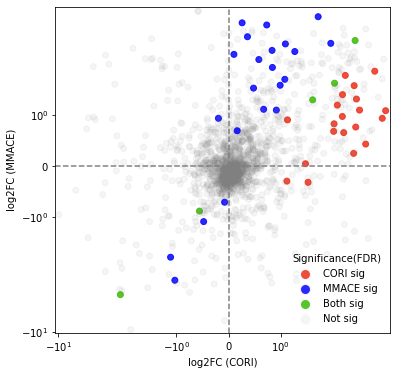

In [78]:


# color based on significance in either CORI or MMACE, if CORI sig then red, if MMACE sig then blue, if both then purple, else grey
color_list = []
for i in range(len(volcano_df_list[0])):
    protein = volcano_df_list[0].iloc[i]['protein']
    cori_sig = protein in cori_sig_proteins['protein'].tolist()
    mmace_sig = protein in mmace_sig_proteins['protein'].tolist()
    
    if cori_sig and mmace_sig:
        color_list.append("#3DBB08DC")  # purple
    elif cori_sig:
        color_list.append("#EB331EDC")  # red
    elif mmace_sig:
        color_list.append("#0000FFD6")  # blue
    else:
        color_list.append("#80808013")  # grey
        
# make scatterplot for log2FC of CORI vs MMACE
plt.figure(figsize=(6, 6))
plt.scatter(volcano_df_list[0]['log2FC'], volcano_df_list[1]['log2FC'],  c=color_list)
plt.xlabel('log2FC (CORI)')
plt.ylabel('log2FC (MMACE)')
# plt.title('Scatter plot of log2FC for CORI vs MMACE')   

# vertical and horizontal lines at 0
plt.axvline(x=0, color='grey', linestyle='--')
plt.axhline(y=0, color='grey', linestyle='--')

# x and y log scale
plt.xscale('symlog')
plt.yscale('symlog')

plt.legend(handles=[
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#EB331EDC', markersize=10, label='CORI sig'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#0000FFD6', markersize=10, label='MMACE sig'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#3DBB08DC', markersize=10, label='Both sig'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#80808013', markersize=10, label='Not sig')
],
           title='Significance(FDR)',   fontsize=10, frameon=False)

# # Add text labels for proteins that are significant in either CORI or MMACE
# from adjustText import adjust_text

# top10_cori = volcano_df_list[0].sort_values('pval_fdr').head(10)['protein'].tolist()
# top10_mmace = volcano_df_list[1].sort_values('pval_fdr').head(10)['protein'].tolist()
# top10_joint = list(set(top10_cori + top10_mmace))

# texts = []
# color_list = []
# for i in range(len(volcano_df_list[0])):
#     protein = volcano_df_list[0].iloc[i]['protein']
#     if protein in top10_joint:
#         texts.append(plt.text(volcano_df_list[0].iloc[i]['log2FC'], volcano_df_list[1].iloc[i]['log2FC'], protein, fontsize=8))
#         color_list.append("red")  # purple for top10 proteins
#     elif protein in cori_sig_proteins['protein'].tolist():
#         texts.append(plt.text(volcano_df_list[0].iloc[i]['log2FC'], volcano_df_list[1].iloc[i]['log2FC'], protein, fontsize=8))
#         color_list.append("red")  # red for CORI sig proteins
#     elif protein in mmace_sig_proteins['protein'].tolist():
#         texts.append(plt.text(volcano_df_list[0].iloc[i]['log2FC'], volcano_df_list[1].iloc[i]['log2FC'], protein, fontsize=8))
#         color_list.append("blue")  # blue for MMACE sig proteins

# adjust_text(texts, arrowprops=dict(arrowstyle='->', color= color_list))


plt.savefig("./figures/log2FC_scatter_CORI_MMACE.png", dpi=300, bbox_inches='tight')
plt.savefig("./figures/log2FC_scatter_CORI_MMACE.svg", dpi=300, bbox_inches='tight')